# Task 2 — Understanding Vision Transformers

## Setup

In [6]:
!pip install -q transformers

In [7]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from PIL import Image

from transformers import (
    AutoImageProcessor,
    ViTForImageClassification,
)


SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


RESULTS_DIR = Path("task2/results")
RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


## 2.1 Pre-trained ViT for Image Classification

In [8]:
MODEL_NAME = "google/vit-base-patch16-224"


processor = AutoImageProcessor.from_pretrained(
    MODEL_NAME
)

model = ViTForImageClassification.from_pretrained(
    MODEL_NAME
)

model = model.to(device)
model.eval()


print("Model:", MODEL_NAME)
print("Image size:", model.config.image_size)
print("Patch size:", model.config.patch_size)
print("Attention heads:", model.config.num_attention_heads)
print("Transformer layers:", model.config.num_hidden_layers)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

Fast image processor class <class 'transformers.models.vit.image_processing_vit_fast.ViTImageProcessorFast'> is available for this model. Using slow image processor class. To use the fast image processor class set `use_fast=True`.


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Model: google/vit-base-patch16-224
Image size: 224
Patch size: 16
Attention heads: 12
Transformer layers: 12


### Test Images

In [9]:
image_paths = [
    Path("/kaggle/input/datasets/sohauvv/task2-pics/bird.jpg"),
    Path("/kaggle/input/datasets/sohauvv/task2-pics/car.jpg"),
    Path("/kaggle/input/datasets/sohauvv/task2-pics/dog.jpg"),
]

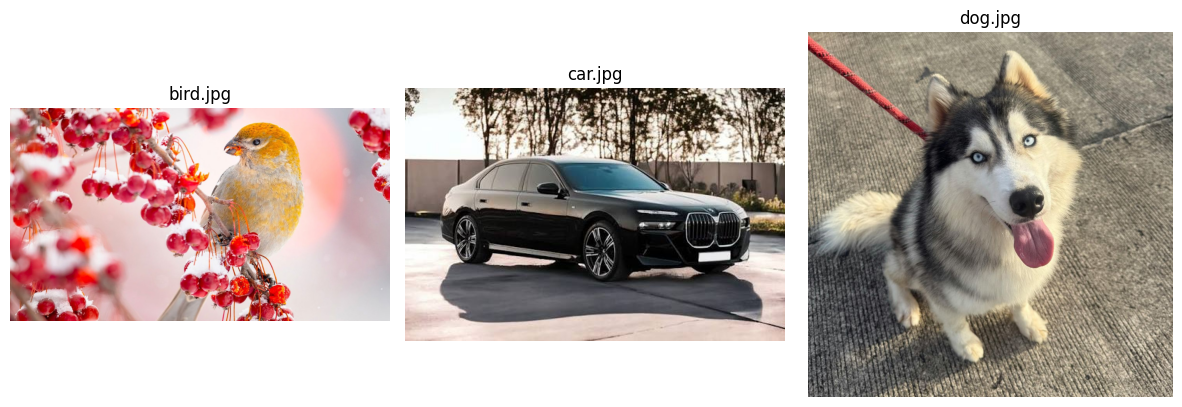

In [10]:
images = [
    Image.open(path).convert("RGB")
    for path in image_paths
]

plt.figure(figsize=(12, 4))

for i, (image, path) in enumerate(zip(images, image_paths)):
    plt.subplot(1, 3, i + 1)
    plt.imshow(image)
    plt.title(path.name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Top-1 ImageNet Predictions

In [11]:
prediction_results = []


for image, path in zip(images, image_paths):
    inputs = processor(
        images=image,
        return_tensors="pt",
    )

    inputs = {
        key: value.to(device)
        for key, value in inputs.items()
    }

    with torch.no_grad():
        outputs = model(**inputs)

    predicted_idx = (
        outputs.logits.argmax(dim=-1).item()
    )

    predicted_label = model.config.id2label[
        predicted_idx
    ]

    confidence = torch.softmax(
        outputs.logits,
        dim=-1,
    )[0, predicted_idx].item()


    prediction_results.append({
        "image": Path(path).name,
        "prediction": predicted_label,
        "confidence": confidence,
    })


prediction_df = pd.DataFrame(
    prediction_results
)

prediction_df

,image,prediction,confidence
0,bird.jpg,"brambling, Fringilla montifringilla",0.152872
1,car.jpg,"sports car, sport car",0.457716
2,dog.jpg,"Eskimo dog, husky",0.659193


In [12]:
prediction_path = (
    RESULTS_DIR /
    "vit_predictions.csv"
)

prediction_df.to_csv(
    prediction_path,
    index=False,
)

print("Saved to:", prediction_path)

Saved to: task2/results/vit_predictions.csv


## 2.2 Visualizing Patch Attention

### Final-Layer CLS Attention

In [13]:
attention_image = images[2]  # dog.jpg


# Force standard attention implementation so attention
# weights are returned by the model
model.config._attn_implementation = "eager"

for layer in model.vit.encoder.layer:
    layer.attention.attention.config._attn_implementation = "eager"


inputs = processor(
    images=attention_image,
    return_tensors="pt",
)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}


with torch.no_grad():
    outputs = model(
        **inputs,
        output_attentions=True,
        return_dict=True,
    )


attentions = outputs.attentions


print("Number of transformer layers:", len(attentions))
print("Final attention shape:", attentions[-1].shape)

Number of transformer layers: 12
Final attention shape: torch.Size([1, 12, 197, 197])


### CLS-to-Patch Attention Map

In [14]:
final_attention = attentions[-1]


# Average attention across all heads
mean_attention = final_attention.mean(dim=1)


# CLS token is index 0.
# Ignore CLS-to-CLS attention and keep CLS-to-patch attention.
cls_attention = mean_attention[
    0,
    0,
    1:,
]


patch_grid_size = int(
    cls_attention.numel() ** 0.5
)

attention_map = cls_attention.reshape(
    patch_grid_size,
    patch_grid_size,
)


print("Patch grid:", attention_map.shape)

Patch grid: torch.Size([14, 14])


### Attention Overlay

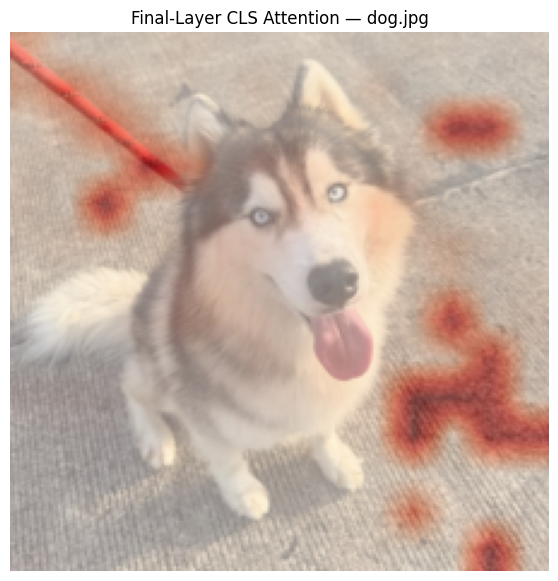

Saved to: task2/results/vit_dog_attention_overlay.png


In [15]:
attention_map = attention_map.unsqueeze(
    0
).unsqueeze(
    0
)


attention_map = F.interpolate(
    attention_map,
    size=(224, 224),
    mode="bilinear",
    align_corners=False,
)


attention_map = attention_map.squeeze().cpu().numpy()


# Normalize for visualization
attention_map = (
    attention_map - attention_map.min()
) / (
    attention_map.max()
    - attention_map.min()
    + 1e-8
)


processed_image = processor(
    images=attention_image,
    return_tensors="pt",
)["pixel_values"][0]


# Undo normalization for display
image_mean = np.array(
    processor.image_mean
).reshape(3, 1, 1)

image_std = np.array(
    processor.image_std
).reshape(3, 1, 1)


display_image = (
    processed_image.numpy()
    * image_std
    + image_mean
)

display_image = np.clip(
    display_image,
    0,
    1,
)

display_image = np.transpose(
    display_image,
    (1, 2, 0),
)


plt.figure(figsize=(7, 7))

plt.imshow(display_image)

plt.imshow(
    attention_map,
    cmap="Reds",
    alpha=0.5,
)

plt.axis("off")

plt.title(
    "Final-Layer CLS Attention — dog.jpg"
)


attention_path = (
    RESULTS_DIR /
    "vit_dog_attention_overlay.png"
)

plt.savefig(
    attention_path,
    bbox_inches="tight",
)

plt.show()


print("Saved to:", attention_path)

## 2.3 Attention Map Analysis

The attention visualization generated above is analyzed in the accompanying report.

## 2.4 Masking High-Attention Patches

In [16]:
# Number of patches to mask: top 10% of the 196 patches
num_patches = patch_grid_size ** 2
num_masked = int(0.10 * num_patches)

attention_scores = cls_attention.detach().cpu().numpy()

top_patch_indices = np.argsort(
    attention_scores
)[-num_masked:]


rng = np.random.default_rng(SEED)

random_patch_indices = rng.choice(
    num_patches,
    size=num_masked,
    replace=False,
)


print("Total patches:", num_patches)
print("Patches masked:", num_masked)

Total patches: 196
Patches masked: 19


In [17]:
def mask_patches(pixel_values, patch_indices, patch_size=16):
    masked = pixel_values.clone()

    # Use zero in normalized pixel space
    # to mask selected patches
    for patch_idx in patch_indices:
        row = patch_idx // patch_grid_size
        col = patch_idx % patch_grid_size

        y1 = row * patch_size
        y2 = y1 + patch_size

        x1 = col * patch_size
        x2 = x1 + patch_size

        masked[
            :,
            :,
            y1:y2,
            x1:x2,
        ] = 0

    return masked


original_pixels = inputs["pixel_values"]


high_attention_pixels = mask_patches(
    original_pixels,
    top_patch_indices,
)


random_pixels = mask_patches(
    original_pixels,
    random_patch_indices,
)

### Masked Image Visualization

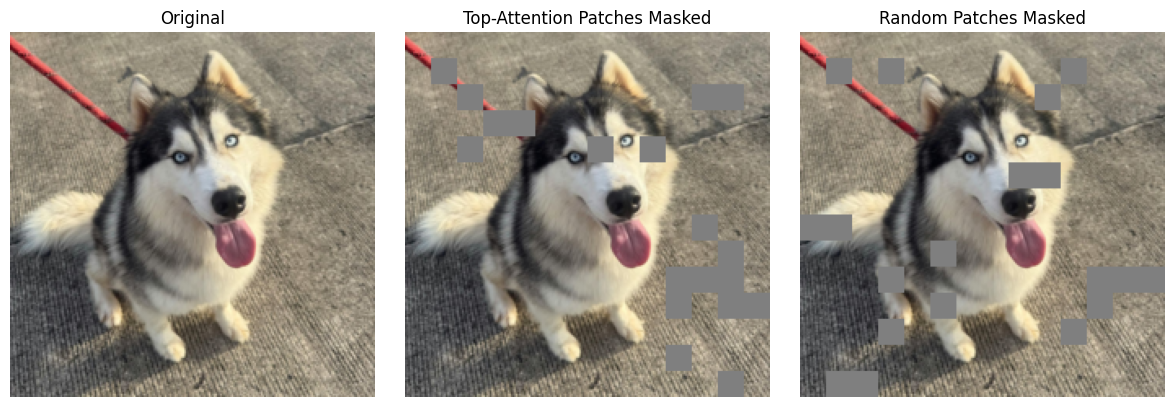

Saved to: task2/results/vit_patch_masking.png


In [18]:
def pixel_values_to_image(pixel_values):
    image = pixel_values[0].detach().cpu().numpy()

    image = (
        image * image_std
        + image_mean
    )

    image = np.clip(
        image,
        0,
        1,
    )

    return np.transpose(
        image,
        (1, 2, 0),
    )


high_attention_image = pixel_values_to_image(
    high_attention_pixels
)

random_mask_image = pixel_values_to_image(
    random_pixels
)


plt.figure(figsize=(12, 4))


plt.subplot(1, 3, 1)
plt.imshow(display_image)
plt.title("Original")
plt.axis("off")


plt.subplot(1, 3, 2)
plt.imshow(high_attention_image)
plt.title("Top-Attention Patches Masked")
plt.axis("off")


plt.subplot(1, 3, 3)
plt.imshow(random_mask_image)
plt.title("Random Patches Masked")
plt.axis("off")


plt.tight_layout()


mask_path = (
    RESULTS_DIR /
    "vit_patch_masking.png"
)

plt.savefig(
    mask_path,
    bbox_inches="tight",
)

plt.show()


print("Saved to:", mask_path)

### Confidence Comparison

In [19]:
def get_class_confidence(pixel_values, class_idx):
    with torch.no_grad():
        outputs = model(
            pixel_values=pixel_values
        )

    probabilities = torch.softmax(
        outputs.logits,
        dim=-1,
    )

    return probabilities[
        0,
        class_idx,
    ].item()


# Original predicted class
with torch.no_grad():
    original_outputs = model(
        pixel_values=original_pixels
    )

original_class_idx = (
    original_outputs.logits.argmax(dim=-1).item()
)

original_class = model.config.id2label[
    original_class_idx
]


original_confidence = get_class_confidence(
    original_pixels,
    original_class_idx,
)

high_attention_confidence = get_class_confidence(
    high_attention_pixels,
    original_class_idx,
)

random_confidence = get_class_confidence(
    random_pixels,
    original_class_idx,
)


masking_results = pd.DataFrame({
    "condition": [
        "Original",
        "Top-attention masked",
        "Random masked",
    ],
    "confidence": [
        original_confidence,
        high_attention_confidence,
        random_confidence,
    ],
})


print("Original predicted class:", original_class)

masking_results

Original predicted class: Eskimo dog, husky


,condition,confidence
0,Original,0.659195
1,Top-attention masked,0.665174
2,Random masked,0.477347


In [20]:
masking_results["confidence_drop"] = (
    original_confidence
    - masking_results["confidence"]
)


masking_path = (
    RESULTS_DIR /
    "vit_patch_masking_results.csv"
)

masking_results.to_csv(
    masking_path,
    index=False,
)


print(masking_results)
print("\nSaved to:", masking_path)

              condition  confidence  confidence_drop
0              Original    0.659195         0.000000
1  Top-attention masked    0.665174        -0.005979
2         Random masked    0.477347         0.181848

Saved to: task2/results/vit_patch_masking_results.csv


## 2.5 [CLS] vs Mean-Pooled Patch Embeddings

### CIFAR-10 Feature Extraction

In [21]:
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader
from torchvision import transforms


CIFAR_ROOT = (
    "/kaggle/input/datasets/sohauvv/cifar10-local"
)


vit_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=processor.image_mean,
        std=processor.image_std,
    ),
])


train_dataset_vit = CIFAR10(
    root=CIFAR_ROOT,
    train=True,
    download=False,
    transform=vit_transform,
)

test_dataset_vit = CIFAR10(
    root=CIFAR_ROOT,
    train=False,
    download=False,
    transform=vit_transform,
)


train_loader_vit = DataLoader(
    train_dataset_vit,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)

test_loader_vit = DataLoader(
    test_dataset_vit,
    batch_size=64,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)


print("Train images:", len(train_dataset_vit))
print("Test images:", len(test_dataset_vit))

Train images: 50000
Test images: 10000


### Frozen ViT Embeddings

In [22]:
def extract_vit_embeddings(model, loader):
    model.eval()

    cls_embeddings = []
    mean_embeddings = []
    labels_all = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(
                device,
                non_blocking=True,
            )

            outputs = model.vit(
                pixel_values=images,
                return_dict=True,
            )

            hidden_states = outputs.last_hidden_state

            # [CLS] representation
            cls_features = hidden_states[:, 0, :]

            # Mean of patch tokens, excluding [CLS]
            mean_features = hidden_states[:, 1:, :].mean(
                dim=1
            )

            cls_embeddings.append(
                cls_features.cpu()
            )

            mean_embeddings.append(
                mean_features.cpu()
            )

            labels_all.append(labels)

    return (
        torch.cat(cls_embeddings).numpy(),
        torch.cat(mean_embeddings).numpy(),
        torch.cat(labels_all).numpy(),
    )

In [23]:
train_cls, train_mean, train_labels_vit = (
    extract_vit_embeddings(
        model,
        train_loader_vit,
    )
)


test_cls, test_mean, test_labels_vit = (
    extract_vit_embeddings(
        model,
        test_loader_vit,
    )
)


print("Train CLS:", train_cls.shape)
print("Train mean:", train_mean.shape)

print("Test CLS:", test_cls.shape)
print("Test mean:", test_mean.shape)

Train CLS: (50000, 768)
Train mean: (50000, 768)
Test CLS: (10000, 768)
Test mean: (10000, 768)


### Linear Probe Comparison

In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler


cls_scaler = StandardScaler()

train_cls_scaled = cls_scaler.fit_transform(
    train_cls
)

test_cls_scaled = cls_scaler.transform(
    test_cls
)


mean_scaler = StandardScaler()

train_mean_scaled = mean_scaler.fit_transform(
    train_mean
)

test_mean_scaled = mean_scaler.transform(
    test_mean
)

In [25]:
cls_probe = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
)

cls_probe.fit(
    train_cls_scaled,
    train_labels_vit,
)


mean_probe = LogisticRegression(
    max_iter=1000,
    random_state=SEED,
)

mean_probe.fit(
    train_mean_scaled,
    train_labels_vit,
)


cls_predictions = cls_probe.predict(
    test_cls_scaled
)

mean_predictions = mean_probe.predict(
    test_mean_scaled
)


cls_accuracy = accuracy_score(
    test_labels_vit,
    cls_predictions,
)

mean_accuracy = accuracy_score(
    test_labels_vit,
    mean_predictions,
)


print(
    f"CLS Linear Probe Accuracy: "
    f"{cls_accuracy:.4f}"
)

print(
    f"Mean-Pooled Linear Probe Accuracy: "
    f"{mean_accuracy:.4f}"
)

CLS Linear Probe Accuracy: 0.9584
Mean-Pooled Linear Probe Accuracy: 0.9627


### Linear Probe Results

In [26]:
probe_results = pd.DataFrame({
    "representation": [
        "CLS token",
        "Mean-pooled patches",
    ],
    "test_accuracy": [
        cls_accuracy,
        mean_accuracy,
    ],
})


probe_path = (
    RESULTS_DIR /
    "vit_linear_probe_results.csv"
)


probe_results.to_csv(
    probe_path,
    index=False,
)


print(probe_results)
print("\nSaved to:", probe_path)

        representation  test_accuracy
0            CLS token         0.9584
1  Mean-pooled patches         0.9627

Saved to: task2/results/vit_linear_probe_results.csv


## Dataset-Level Patch-Masking Accuracy

The earlier single-image experiment examined whether final-layer attention magnitude corresponded to causal importance. To directly satisfy the robustness experiment, patch masking is now evaluated over the complete CIFAR-10 test set using the mean-pooled linear probe from Section 2.5.

We mask exactly 49 of the 196 ViT patches, corresponding to 25% of the input. Two masking strategies are compared:

1. **Random masking:** 49 patch locations are sampled independently for each image.
2. **Structured center masking:** a contiguous 7 × 7 block of central patches is removed.

Both strategies therefore remove exactly the same amount of visual information. Classification accuracy after masking is compared with the unmasked mean-pooled linear-probe accuracy.

In [27]:
PATCH_GRID = 14
PATCH_SIZE = 16

NUM_PATCHES = PATCH_GRID ** 2
NUM_MASKED = 49  # 7 x 7 = exactly 25% of 196 patches

print("Total patches:", NUM_PATCHES)
print("Masked patches:", NUM_MASKED)
print(f"Masked fraction: {NUM_MASKED / NUM_PATCHES:.2%}")


def patch_mask_to_pixels(patch_mask):
    """
    Convert a patch-level boolean mask of shape
    [B, 1, 14, 14] into a pixel mask [B, 1, 224, 224].
    """
    return (
        patch_mask
        .repeat_interleave(PATCH_SIZE, dim=2)
        .repeat_interleave(PATCH_SIZE, dim=3)
    )


def make_random_patch_mask(batch_size, generator):
    """
    Select exactly NUM_MASKED random patches independently
    for every image in the batch.
    """
    scores = torch.rand(
        batch_size,
        NUM_PATCHES,
        generator=generator,
    )

    indices = scores.topk(
        NUM_MASKED,
        dim=1,
    ).indices

    patch_mask = torch.zeros(
        batch_size,
        NUM_PATCHES,
        dtype=torch.bool,
    )

    patch_mask.scatter_(
        1,
        indices,
        True,
    )

    return patch_mask.view(
        batch_size,
        1,
        PATCH_GRID,
        PATCH_GRID,
    )


def make_center_patch_mask(batch_size):
    """
    Mask one contiguous 7 x 7 block near the center
    of the 14 x 14 patch grid.
    """
    patch_mask = torch.zeros(
        batch_size,
        1,
        PATCH_GRID,
        PATCH_GRID,
        dtype=torch.bool,
    )

    block_size = 7
    start = (PATCH_GRID - block_size) // 2
    end = start + block_size

    patch_mask[
        :,
        :,
        start:end,
        start:end,
    ] = True

    return patch_mask

Total patches: 196
Masked patches: 49
Masked fraction: 25.00%


In [28]:
def extract_masked_mean_embeddings(
    model,
    loader,
    masking_strategy,
):
    model.eval()

    embeddings = []
    labels_all = []

    # Reproducible random masks
    generator = torch.Generator()
    generator.manual_seed(SEED)

    with torch.no_grad():
        for images, labels in loader:
            batch_size = images.size(0)

            if masking_strategy == "random":
                patch_mask = make_random_patch_mask(
                    batch_size,
                    generator,
                )

            elif masking_strategy == "center":
                patch_mask = make_center_patch_mask(
                    batch_size
                )

            else:
                raise ValueError(
                    "masking_strategy must be "
                    "'random' or 'center'"
                )

            pixel_mask = patch_mask_to_pixels(
                patch_mask
            ).to(device)

            images = images.to(
                device,
                non_blocking=True,
            )

            # Zero corresponds to the preprocessing mean
            # in normalized image space.
            masked_images = images.masked_fill(
                pixel_mask,
                0.0,
            )

            outputs = model.vit(
                pixel_values=masked_images,
                return_dict=True,
            )

            hidden_states = (
                outputs.last_hidden_state
            )

            # Use the same representation as the
            # best-performing probe in Section 2.5.
            mean_features = (
                hidden_states[:, 1:, :].mean(dim=1)
            )

            embeddings.append(
                mean_features.cpu()
            )

            labels_all.append(labels)

    return (
        torch.cat(embeddings).numpy(),
        torch.cat(labels_all).numpy(),
    )

In [29]:
random_mask_mean, random_mask_labels = (
    extract_masked_mean_embeddings(
        model,
        test_loader_vit,
        masking_strategy="random",
    )
)

center_mask_mean, center_mask_labels = (
    extract_masked_mean_embeddings(
        model,
        test_loader_vit,
        masking_strategy="center",
    )
)


print("Random-mask features:", random_mask_mean.shape)
print("Center-mask features:", center_mask_mean.shape)

Random-mask features: (10000, 768)
Center-mask features: (10000, 768)


In [30]:
random_mask_scaled = mean_scaler.transform(
    random_mask_mean
)

center_mask_scaled = mean_scaler.transform(
    center_mask_mean
)


random_predictions = mean_probe.predict(
    random_mask_scaled
)

center_predictions = mean_probe.predict(
    center_mask_scaled
)


random_mask_accuracy = accuracy_score(
    random_mask_labels,
    random_predictions,
)

center_mask_accuracy = accuracy_score(
    center_mask_labels,
    center_predictions,
)


print(
    f"Original accuracy:      "
    f"{mean_accuracy:.4f}"
)

print(
    f"Random-mask accuracy:   "
    f"{random_mask_accuracy:.4f}"
)

print(
    f"Center-mask accuracy:   "
    f"{center_mask_accuracy:.4f}"
)

print()

print(
    f"Random accuracy drop:   "
    f"{mean_accuracy - random_mask_accuracy:.4f}"
)

print(
    f"Center accuracy drop:   "
    f"{mean_accuracy - center_mask_accuracy:.4f}"
)

Original accuracy:      0.9627
Random-mask accuracy:   0.9174
Center-mask accuracy:   0.7702

Random accuracy drop:   0.0453
Center accuracy drop:   0.1925


In [31]:
masking_accuracy_results = pd.DataFrame({
    "condition": [
        "Original",
        "Random 25% masking",
        "Center 25% masking",
    ],
    "test_accuracy": [
        mean_accuracy,
        random_mask_accuracy,
        center_mask_accuracy,
    ],
})


masking_accuracy_results["accuracy_drop"] = (
    mean_accuracy
    - masking_accuracy_results["test_accuracy"]
)


masking_accuracy_path = (
    RESULTS_DIR /
    "vit_patch_masking_accuracy.csv"
)

masking_accuracy_results.to_csv(
    masking_accuracy_path,
    index=False,
)


masking_accuracy_results

,condition,test_accuracy,accuracy_drop
0,Original,0.9627,0.0000
1,Random 25% masking,0.9174,0.0453
2,Center 25% masking,0.7702,0.1925


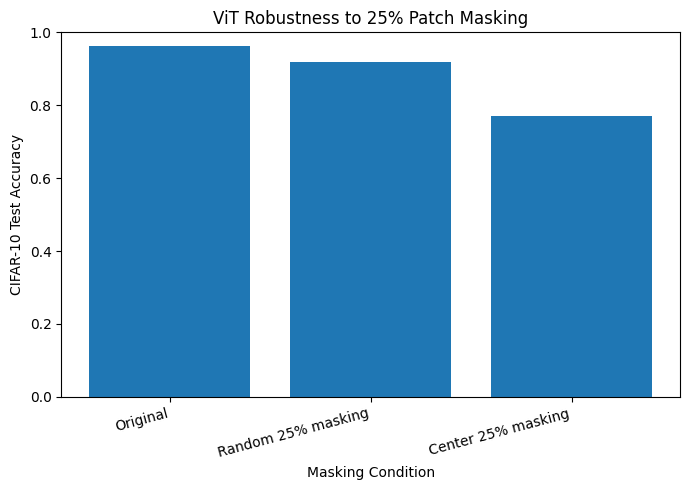

Saved CSV to: task2/results/vit_patch_masking_accuracy.csv
Saved figure to: task2/results/vit_patch_masking_accuracy.png


In [32]:
plt.figure(figsize=(7, 5))

plt.bar(
    masking_accuracy_results["condition"],
    masking_accuracy_results["test_accuracy"],
)

plt.ylabel("CIFAR-10 Test Accuracy")
plt.xlabel("Masking Condition")

plt.title(
    "ViT Robustness to 25% Patch Masking"
)

plt.ylim(
    0,
    1.0,
)

plt.xticks(
    rotation=15,
    ha="right",
)

plt.tight_layout()


masking_accuracy_fig_path = (
    RESULTS_DIR /
    "vit_patch_masking_accuracy.png"
)

plt.savefig(
    masking_accuracy_fig_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


print(
    "Saved CSV to:",
    masking_accuracy_path,
)

print(
    "Saved figure to:",
    masking_accuracy_fig_path,
)